In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)

df["HouseValue"] = housing.target

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Dataset Column Meanings

1. **MedInc**  
   Median income of households in the area (in tens of thousands of dollars).  
   Example: 8.3252 ≈ $83,252 median income.

2. **HouseAge**  
   Median age of houses in the area (in years).

3. **AveRooms**  
   Average number of rooms per household in the area.

4. **AveBedrms**  
   Average number of bedrooms per household.

5. **Population**  
   Total population living in the block group.

6. **AveOccup**  
   Average number of people living in each household.

7. **Latitude**  
   Geographic latitude of the district.

8. **Longitude**  
   Geographic longitude of the district.

9. **HouseValue**  
   Median house value in the area (in hundreds of thousands of dollars).

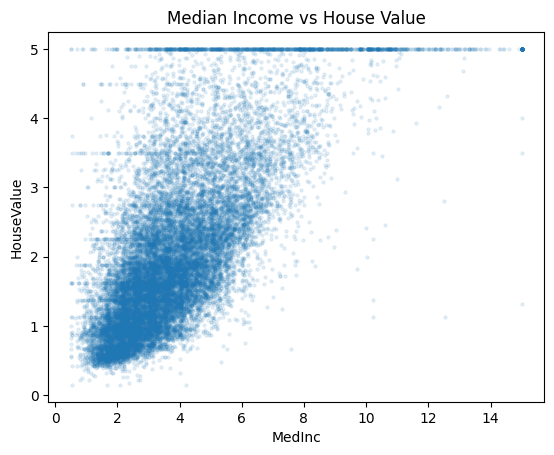

In [2]:
df.plot.scatter(x="MedInc", y="HouseValue", alpha=0.1,s=5)

plt.title("Median Income vs House Value")
plt.show()

We can oberserve that having a higher median inc leads to have a higher house value (more expensive). But the data caps the housing value at 500k, which is a limitation of the data set. Because of this we will remove these observation so that the Linear Regression Model is more accurate.

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
sdf = df[df["HouseValue"] < 5].copy()

# Single Linear Regression

In [5]:
model_s = LinearRegression()

model_s.fit(X = sdf[["MedInc"]],y = sdf['HouseValue'])
print("Intercept:", model_s.intercept_)
print("Slope:", model_s.coef_[0])

Intercept: 0.45047145148615053
Slope: 0.39986877559792133


In [6]:
mdf = df[df["HouseValue"] < 5].copy()
model_m = LinearRegression()
model_m.fit(X=mdf[["MedInc", "HouseAge",'AveRooms','AveBedrms','Population','AveOccup']],y=mdf["HouseValue"])
print("Intercept:", model_m.intercept_)
print("Slopes:", model_m.coef_)

Intercept: -0.4239696062161791
Slopes: [ 5.47509166e-01  1.49107987e-02 -2.22739191e-01  9.83294876e-01
  2.66842032e-05 -4.49274679e-03]


In [7]:
from sklearn.metrics import r2_score

print("Simple model R²:", model_s.score(sdf[["MedInc"]], sdf["HouseValue"]))
print("Multiple model R²:", model_m.score(
    mdf[["MedInc","HouseAge","AveRooms","AveBedrms","Population","AveOccup"]],
    mdf["HouseValue"]
))

Simple model R²: 0.41824601638696524
Multiple model R²: 0.4998097072659219
